## libs import

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

## connection

In [2]:
connection = sqlite3.connect('../data/checking-logs.sqlite')

## query for date from checker for users

In [3]:
query = """
SELECT timestamp, uid
FROM checker
WHERE uid LIKE 'user_%';
"""
df = pd.read_sql_query(query, connection)

## df preproccesing

In [4]:
df['weekday_name'] = pd.to_datetime(df['timestamp']).dt.strftime("%a")
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour

In [5]:
commit_per_day = pd.DataFrame(df[['uid', 'weekday_name']].value_counts()).reset_index()
commit_per_hour = pd.DataFrame(df[['uid', 'hour']].value_counts()).reset_index()
for_sorting = df.uid.value_counts()

In [6]:
commit_per_day_sorted = commit_per_day.merge(for_sorting, 
                                             left_on='uid', 
                                             right_index=True, 
                                             suffixes=('_day', '_all')).sort_values(by='count_all', ascending=False).set_index('uid')

In [7]:
commit_per_hour_sorted = commit_per_hour.merge(for_sorting, 
                                             left_on='uid', 
                                             right_index=True, 
                                             suffixes=('_hour', '_all')).sort_values(by='count_all', ascending=False).set_index('uid')

## pivot tables creating: commits per day and per hour

In [9]:
pivot_data_day = commit_per_day_sorted.reset_index().pivot_table(index='weekday_name', columns='uid', values='count_day', fill_value=0, sort = False).reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
pivot_data_hour = commit_per_hour_sorted.reset_index().pivot_table(index='hour', columns='uid', values='count_hour', fill_value=0, sort = False).sort_index()

In [10]:
pivot_data_day.head()

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_11,user_22,user_7,user_23,user_0
weekday_name,,,,,,,,,,,,,,,,,,,,,
Mon,35.0,50.0,24.0,14.0,7.0,0.0,23.0,5.0,0.0,46.0,...,8.0,10.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,3.0
Tue,86.0,87.0,131.0,44.0,9.0,1.0,0.0,0.0,16.0,11.0,...,4.0,5.0,0.0,0.0,0.0,0.0,3.0,5.0,0.0,0.0
Wed,33.0,0.0,32.0,15.0,0.0,34.0,8.0,0.0,37.0,0.0,...,1.0,0.0,0.0,0.0,4.0,0.0,0.0,3.0,0.0,0.0
Thu,108.0,17.0,4.0,40.0,78.0,51.0,96.0,7.0,77.0,7.0,...,17.0,14.0,15.0,5.0,2.0,0.0,2.0,0.0,6.0,0.0
Fri,61.0,0.0,0.0,10.0,10.0,2.0,7.0,35.0,1.0,59.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
pivot_data_hour.head()

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_11,user_22,user_7,user_23,user_0
hour,,,,,,,,,,,,,,,,,,,,,
0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
1,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,13.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Plot. Commits per day and per hour by users

In [53]:
def create_heatmap(ax, data, cmap, title=None):
    # Рисуем heatmap
    c = ax.imshow(data, cmap=cmap, interpolation='nearest', aspect='auto')
    cbar = plt.colorbar(c, ax=ax, pad=0.02)  # Добавляем цветовую шкалу
    cbar_pos = ax.get_position()  # Получаем положение основного графика
    cbar.ax.set_position([cbar_pos.x1 + 0.1, cbar_pos.y0, 0.1, cbar_pos.height]) 

    # Настраиваем оси
    ax.set_yticks(range(data.shape[0]))  # Устанавливаем позиции делений по оси Y
    ax.set_xticks(range(data.shape[1]))  # Устанавливаем позиции делений по оси X
    ax.set_yticklabels(data.index)  # Устанавливаем метки по оси Y
    ax.set_xticklabels(data.columns, rotation=90)  # Устанавливаем метки по оси X

    # Добавляем заголовок (если указан)
    if title:
        ax.set_title(title)

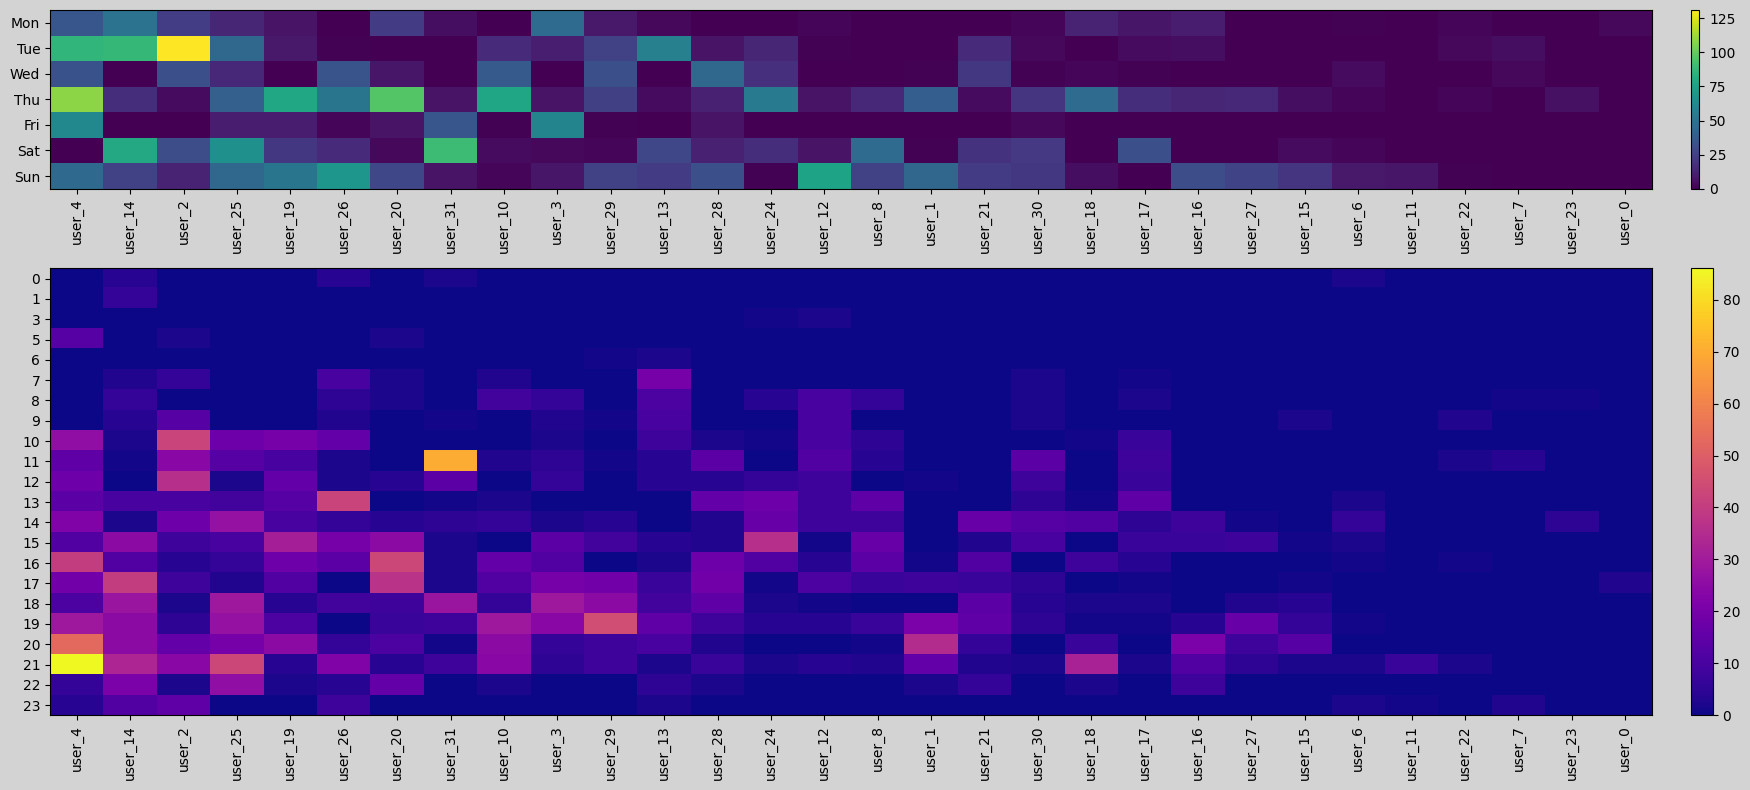

In [54]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 8), gridspec_kw={'height_ratios': [0.4, 1]})
fig.patch.set_facecolor('lightgrey')
ax1.set_facecolor('lightgrey')
ax2.set_facecolor('lightgrey')
# Рисуем и настраиваем первый heatmap (верхний)
create_heatmap(ax1, pivot_data_day, cmap='viridis')

# Рисуем и настраиваем второй heatmap (нижний)
create_heatmap(ax2, pivot_data_hour, cmap='plasma')

# Настраиваем отображение
plt.tight_layout()  # Убираем лишние пробелы
plt.show()  # Отображаем график

## Answer for questions:

### “Which user has the most commits on Tue?” The answer: user_2.
### “Which user has the most commits on Thu?” The answer: user_4.
### “On which weekday do the users not like making a lot of commits?” The answer: Fri.
### “Which user at which hour made the largest number of commits?” The answer: user_4, 21

## connection close

In [55]:
connection.close()